# Clustering

Clustering techniques are unsupervised learning algorithms that try to group unlabelled data into "clusters", using the (typically spatial) structure of the data itself. It has many [applications](https://en.wikipedia.org/wiki/Cluster_analysis#Applications).

The easiest way to demonstrate how clustering works is to simply generate some data and show them in action. We'll start off by importing the libraries we'll be using today.

In [ ]:
import math, matplotlib.pyplot as plt, operator, torch
from functools import partial

In [ ]:
torch.manual_seed(42)
torch.set_printoptions(precision=3, linewidth=140, sci_mode=False)

## Create data

In [ ]:
n_clusters=6
n_samples =250

To generate our data, we're going to pick 6 random points, which we'll call centroids, and for each point we're going to generate 250 random points about it.

In [ ]:
centroids = torch.rand(n_clusters, 2)*70-35

In [ ]:
from torch.distributions.multivariate_normal import MultivariateNormal
from torch import tensor

In [ ]:
def sample(m): return MultivariateNormal(m, torch.diag(tensor([5.,5.]))).sample((n_samples,))

In [ ]:
slices = [sample(c) for c in centroids]
data = torch.cat(slices)
data.shape

torch.Size([1500, 2])

Below we can see each centroid marked w/ X, and the coloring associated to each respective cluster.

In [ ]:
def plot_data(centroids, data, n_samples, ax=None):
    if ax is None: _,ax = plt.subplots()
    for i, centroid in enumerate(centroids):
        samples = data[i*n_samples:(i+1)*n_samples]
        ax.scatter(samples[:,0], samples[:,1], s=1)
        ax.plot(*centroid, markersize=10, marker="x", color='k', mew=5)
        ax.plot(*centroid, markersize=5, marker="x", color='m', mew=2)

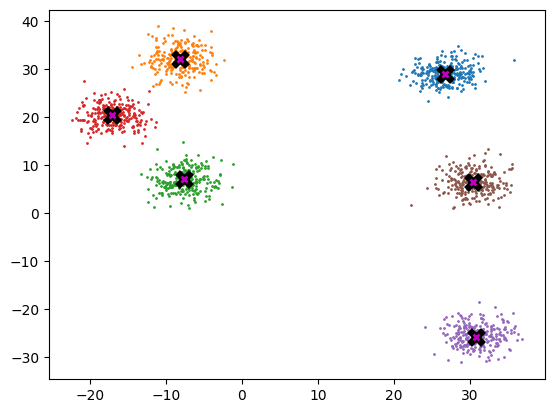

In [ ]:
plot_data(centroids, data, n_samples)

## Mean shift

在中文和英文的语境中分别说明Mean shift这两个单词组合的意思

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！我们来看一下 **Mean shift** 在中文和英文语境中的各自含义。

---

### 英文语境：Mean shift

拆开来看：

- **Mean** → 平均值、均值
- **Shift** → 移动、偏移

所以字面意思就是 **"移动均值"** 或 **"均值偏移"**。

作为一个算法名字，它描述的是算法的核心动作：**不断地把每个数据点向它周围邻居的平均位置移动**，反复迭代直到收敛。点往哪移？往“密度更高”的地方移——最终所有点会聚集到几个“密度中心”，也就是我们找出的聚类中心。

---

### 中文语境：均值漂移

中文通常把它翻译为 **均值漂移**：

- **均值** ≈ mean（平均值）
- **漂移** ≈ shift（缓慢移动、飘移）

"漂移"这个词选得挺形象的——想象一下，每个点就像一片树叶，在数据空间的"密度风"中慢慢飘向密度最高的地方（也就是聚类的中心）。不是一个生硬的跳跃，而是一步一步地"漂"过去。

---

### 一句话总结

| 语言 | 术语 | 含义 |
|------|------|------|
| 英文 | **Mean shift** | 不断把点移向局部均值，从而找到密度中心 |
| 中文 | **均值漂移** | 数据点向密度更高的区域“漂移”，最终聚成簇 |

接下来想看看这个算法具体是怎么一步步工作的吗？比如我们可以先从一个点开始，看看它的“邻居”是谁、均值怎么算、往哪移。

<details class='token-usage-details'><summary>$0.0007</summary>

`total=8,533 | in=8,028 | out=505 | cached=73.3% | reasoning=166 | searches=0 | $0.0007`

</details>


Most people that have come across clustering algorithms have learnt about **k-means**. Mean shift clustering is a newer and less well-known approach, but it has some important advantages:
* It doesn't require selecting the number of clusters in advance, but instead just requires a **bandwidth** to be specified, which can be easily chosen automatically
* It can handle clusters of any shape, whereas k-means (without using special extensions) requires that clusters be roughly ball shaped.

比较 mean shift and kmeans

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

可以，从**目标、输入参数、结果、适用场景**四个角度来比最清楚：

| 项目 | k-means | Mean shift |
|---|---|---|
| 核心想法 | 把点分到离自己最近的“中心” | 把点一步步推向“密度更高”的地方 |
| 需要先指定什么 | **簇的个数 k** | **bandwidth（带宽）** |
| 簇的形状 | 更适合“圆团状”簇 | 可以处理更复杂的形状 |
| 输出 | 每个点属于哪个簇 + 每个簇中心 | 自动找到若干个密度峰值作为簇中心 |
| 优点 | 快、简单、常用 | 不用预先指定簇数，能找到任意形状簇 |
| 缺点 | 需要先知道 k；对非球形簇不太好 | 通常更慢；bandwidth 选得不好会影响结果 |

### 直观理解

- **k-means** 像是在问：  
  “我已经知道有几堆了，现在把每个点分到最近的那堆中心去。”

- **Mean shift** 像是在问：  
  “我不知道有几堆，但我想看看数据自己会往哪里‘聚’。”

### 一个很重要的区别

- **k-means 是“先定簇数，再分组”**
- **Mean shift 是“先看密度，再自动找簇”**

所以如果你：
- 已经知道大概有几个群 → **k-means** 更方便
- 不知道有几个群，而且形状可能很奇怪 → **Mean shift** 更有吸引力

如果你愿意，我下一步可以用一张“点怎么移动”的小例子，帮你把 mean shift 的过程讲得更直观。

<details class='token-usage-details'><summary>$0.0180</summary>

`total=13,430 | in=12,918 | out=512 | cached=0.0% | reasoning=83 | searches=0 | $0.0180`

</details>


The algorithm is as follows:
* For each data point x in the sample X, find the distance between that point x and every other point in X
* Create weights for each point in X by using the **Gaussian kernel** of that point's distance to x
    * This weighting approach penalizes points further away from x
    * The rate at which the weights fall to zero is determined by the **bandwidth**, which is the standard deviation of the Gaussian
* Update x as the weighted average of all other points in X, weighted based on the previous step

This will iteratively push points that are close together even closer until they are next to each other.

what is bandwidth?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

In **mean shift**, **bandwidth** is the **neighborhood size** that controls how far each point “looks” when computing its weighted average.

Intuitively:

- **small bandwidth** → only very nearby points matter, so you may get **many small clusters**
- **large bandwidth** → more points influence the average, so clusters can **merge together**

So bandwidth acts like a **smoothing scale**:
it decides whether you see lots of fine detail or only broad blobs.

A good mental picture is a **blur radius** in an image:  
small blur keeps details sharp; large blur makes nearby things blend together.

If you want, I can next show how bandwidth changes the result on a simple 1D example.

<details class='token-usage-details'><summary>$0.0168</summary>

`total=13,793 | in=13,563 | out=230 | cached=0.0% | reasoning=74 | searches=0 | $0.0168`

</details>


In [ ]:
data.shape

torch.Size([1500, 2])

In [ ]:
midp = data.mean(0)
midp

tensor([ 9.222, 11.604])

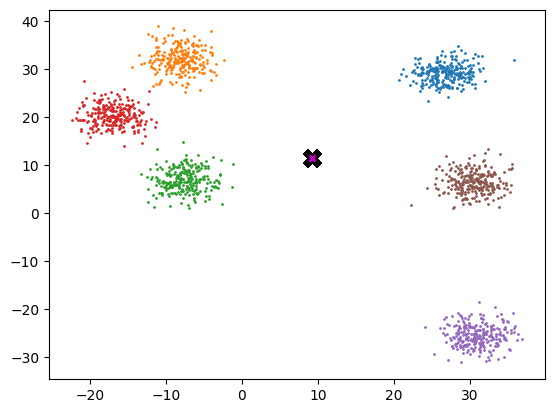

In [ ]:
plot_data([midp]*6, data, n_samples)

So here's the definition of the gaussian kernel, which you may remember from high school...
 This person at the science march certainly remembered!

<img src="http://i.imgur.com/nijQLHw.jpg" width=400>

what is science march

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

“**Science march**” here is probably shorthand for the **March for Science** — a real public rally/protest movement where scientists and supporters marched to promote the value of science and evidence-based policy. The main event happened on **Earth Day, April 22, 2017**, and it became a global set of marches in many cities. ([aaup.org](https://www.aaup.org/march-science?utm_source=openai))

So in that caption, it just means **“at the science protest/march”**, not some special technical phrase. ([en.wikipedia.org](https://en.wikipedia.org/wiki/March_for_Science?utm_source=openai))

<details class='token-usage-details'><summary>$0.0157</summary>

`total=19,469 | in=18,668 | out=801 | cached=56.9% | reasoning=651 | searches=0 | $0.0157`

</details>


Why it happened on Earth Day

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

It was held on **Earth Day, April 22, 2017**, **on purpose**: the organizers planned it to coincide with Earth Day and with related educational/scientific events. The timing helped connect the march with issues like **climate change, environmental literacy, and science in public policy**. ([pbs.org](https://www.pbs.org/newshour/amp/science/march-for-science?utm_source=openai))

So, in short: **Earth Day was chosen because it fit the march’s themes and gave it extra symbolic force and visibility.** ([scientificamerican.com](https://www.scientificamerican.com/article/march-for-science-set-for-earth-day/?utm_source=openai))

<details class='token-usage-details'><summary>$0.0101</summary>

`total=19,167 | in=18,742 | out=425 | cached=73.1% | reasoning=272 | searches=0 | $0.0101`

</details>


In [ ]:
def gaussian(d, bw): return torch.exp(-0.5*((d/bw))**2) / (bw*math.sqrt(2*math.pi))

In [ ]:
def plot_func(f):
    x = torch.linspace(0,10,100)
    plt.plot(x, f(x))

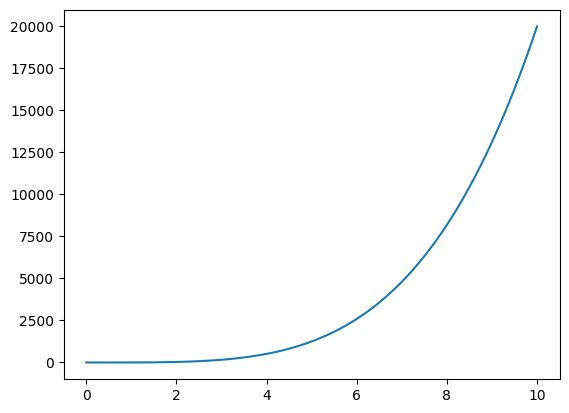

In [ ]:
plot_func(lambda x: 2*x**4)

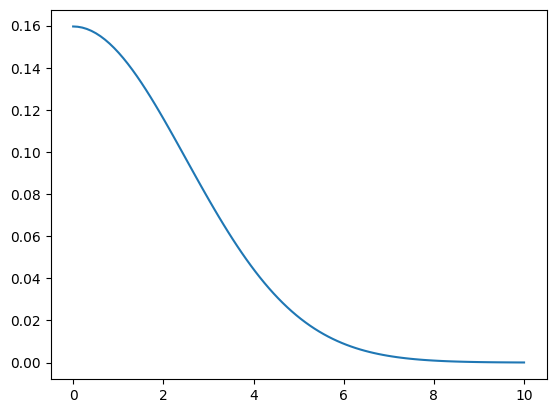

In [ ]:
plot_func(partial(gaussian, bw=2.5))

In [ ]:
partial

functools.partial

In our implementation, we choose the bandwidth to be 2.5. 

One easy way to choose bandwidth is to find which bandwidth covers one third of the data.

In [ ]:
def tri(d, i): return (-d+i).clamp_min(0)/i

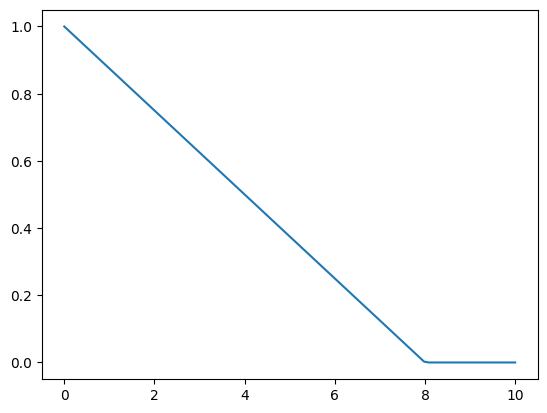

In [ ]:
plot_func(partial(tri, i=8))

In [ ]:
X = data.clone()
x = data[0]

In [ ]:
x

tensor([26.204, 26.349])

In [ ]:
x.shape,X.shape,x[None].shape

(torch.Size([2]), torch.Size([1500, 2]), torch.Size([1, 2]))

In [ ]:
(x[None]-X)[:8]

tensor([[ 0.000,  0.000],
        [ 0.513, -3.865],
        [-4.227, -2.345],
        [ 0.557, -3.685],
        [-5.033, -3.745],
        [-4.073, -0.638],
        [-3.415, -5.601],
        [-1.920, -5.686]])

In [ ]:
(x-X)[:8]

tensor([[ 0.000,  0.000],
        [ 0.513, -3.865],
        [-4.227, -2.345],
        [ 0.557, -3.685],
        [-5.033, -3.745],
        [-4.073, -0.638],
        [-3.415, -5.601],
        [-1.920, -5.686]])

In [ ]:
# rewrite using torch.einsum
dist = ((x-X)**2).sum(1).sqrt()
dist[:8]

tensor([0.000, 3.899, 4.834, 3.726, 6.273, 4.122, 6.560, 6.002])

In [ ]:
dist.shape

torch.Size([1500])

In [ ]:
weight = gaussian(dist, 2.5)
weight

tensor([0.160, 0.047, 0.025,  ..., 0.000, 0.000, 0.000])

In [ ]:
weight.shape,X.shape

(torch.Size([1500]), torch.Size([1500, 2]))

In [ ]:
weight.max(), weight.min()

(tensor(0.160), tensor(0.))

需要设置大于bw的权重为0吗

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！看看我们当前的代码：

```python
def gaussian(d, bw): return torch.exp(-0.5*((d/bw))**2) / (bw*math.sqrt(2*math.pi))
```

高斯函数在数学上是**永远不会等于 0 的**——不管距离多远，它都会给一个很小的权重。但是当距离很大时（比如 `d >> bw`），计算机会因为浮点数精度限制，直接把它当作 0。

所以严格来说**不需要手动设 0**，因为：

- 距离很远的点，权重自动变成计算机能表示的最小值（接近 0）
- 它们对加权平均的贡献可以忽略不计

不过在实际应用中，有一种常见做法叫做 **截断（truncation）**：只考虑距离在 `2.5×bw` 或 `3×bw` 以内的点，之外的直接设权重为 0。这样做的好处是**加速计算**——尤其当数据量很大的时候，每次只算邻居，不用算所有点。

所以答案就是：

- **数学上**：不需要，高斯自己会递减到接近 0
- **工程上**：可以截断来提高速度，是常见的优化技巧

你想试试在我们的代码里加上截断，看看结果会不会变吗？

<details class='token-usage-details'><summary>$0.0002</summary>

`total=12,062 | in=11,557 | out=505 | cached=99.7% | reasoning=232 | searches=0 | $0.0002`

</details>


In [ ]:
weight[:,None].shape

torch.Size([1500, 1])

In [ ]:
weight[:,None]*X

tensor([[4.182, 4.205],
        [1.215, 1.429],
        [0.749, 0.706],
        ...,
        [0.000, 0.000],
        [0.000, 0.000],
        [0.000, 0.000]])

In [ ]:
def one_update(X):
    for i, x in enumerate(X):
        dist = torch.sqrt(((x-X)**2).sum(1))
#         weight = gaussian(dist, 2.5)
        weight = tri(dist, 8)
        X[i] = (weight[:,None]*X).sum(0)/weight.sum()

In [ ]:
def meanshift(data):
    X = data.clone()
    for it in range(5): one_update(X)
    return X

In [ ]:
%time X=meanshift(data)

CPU times: user 326 ms, sys: 0 ns, total: 326 ms
Wall time: 325 ms


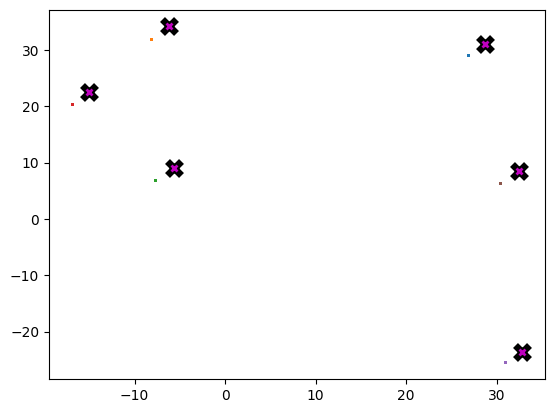

In [ ]:
plot_data(centroids+2, X, n_samples)

## Animation

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [ ]:
def do_one(d):
    if d: one_update(X)
    ax.clear()
    plot_data(centroids+2, X, n_samples, ax=ax)

In [ ]:
# create your own animation
X = data.clone()
fig,ax = plt.subplots()
ani = FuncAnimation(fig, do_one, frames=5, interval=500, repeat=False)
plt.close()
HTML(ani.to_jshtml())

HTML(
<link rel="stylesheet"
href="https://maxcdn.bootstrapcdn.com/font-awesome/4.4.0/css/font-awesome.min.css">
<script language="javascript">
  function isInternetExplorer() {
    ua = navigator.userAgent;
    /* MSIE used to detect old browsers and Trident used to newer ones*/
    return ua.indexOf("MSIE ") > -1 || ua.indexOf("Trident/") > -1;
  }

  /* Define the Animation class */
  function Animation(frames, img_id, slider_id, interval, loop_select_id){
    this.img_id = img_id;
    this.slider_id = slider_id;
    this.loop_select_id = loop_select_id;
    this.interval = interval;
    this.current_frame = 0;
    this.direction = 0;
    this.timer = null;
    this.frames = new Array(frames.length);

    for (var i=0; i<frames.length; i++)
    {
     this.frames[i] = new Image();
     this.frames[i].src = frames[i];
    }
    var slider = document.getElementById(this.slider_id);
    slider.max = this.frames.length - 1;
    if (isInternetExplorer()) {
        // switch from oninput to onchange because IE <= 11 does not conform
        // with W3C specification. It ignores oninput and onchange behaves
        // like oninput. In contrast, Microsoft Edge behaves correctly.
        slider.setAttribute('onchange', slider.getAttribute('oninput'));
        slider.setAttribute('oninput', null);
    }
    this.set_frame(this.current_frame);
  }

  Animation.prototype.get_loop_state = function(){
    var button_group = document[this.loop_select_id].state;
    for (var i = 0; i < button_group.length; i++) {
        var button = button_group[i];
        if (button.checked) {
            return button.value;
        }
    }
    return undefined;
  }

  Animation.prototype.set_frame = function(frame){
    this.current_frame = frame;
    document.getElementById(this.img_id).src =
            this.frames[this.current_frame].src;
    document.getElementById(this.slider_id).value = this.current_frame;
  }

  Animation.prototype.next_frame = function()
  {
    this.set_frame(Math.min(this.frames.length - 1, this.current_frame + 1));
  }

  Animation.prototype.previous_frame = function()
  {
    this.set_frame(Math.max(0, this.current_frame - 1));
  }

  Animation.prototype.first_frame = function()
  {
    this.set_frame(0);
  }

  Animation.prototype.last_frame = function()
  {
    this.set_frame(this.frames.length - 1);
  }

  Animation.prototype.slower = function()
  {
    this.interval /= 0.7;
    if(this.direction > 0){this.play_animation();}
    else if(this.direction < 0){this.reverse_animation();}
  }

  Animation.prototype.faster = function()
  {
    this.interval *= 0.7;
    if(this.direction > 0){this.play_animation();}
    else if(this.direction < 0){this.reverse_animation();}
  }

  Animation.prototype.anim_step_forward = function()
  {
    this.current_frame += 1;
    if(this.current_frame < this.frames.length){
      this.set_frame(this.current_frame);
    }else{
      var loop_state = this.get_loop_state();
      if(loop_state == "loop"){
        this.first_frame();
      }else if(loop_state == "reflect"){
        this.last_frame();
        this.reverse_animation();
      }else{
        this.pause_animation();
        this.last_frame();
      }
    }
  }

  Animation.prototype.anim_step_reverse = function()
  {
    this.current_frame -= 1;
    if(this.current_frame >= 0){
      this.set_frame(this.current_frame);
    }else{
      var loop_state = this.get_loop_state();
      if(loop_state == "loop"){
        this.last_frame();
      }else if(loop_state == "reflect"){
        this.first_frame();
        this.play_animation();
      }else{
        this.pause_animation();
        this.first_frame();
      }
    }
  }

  Animation.prototype.pause_animation = function()
  {
    this.direction = 0;
    if (this.timer){
      clearInterval(this.timer);
      this.timer = null;
    }
  }

  Animation.prototype.play_animation = function()
  {
    this.pause_animation();
    this.direction = 1;
    var t = this;
    if (!this.timer) thi

## GPU batched algorithm

To truly accelerate the algorithm, we need to be performing updates on a batch of points per iteration, instead of just one as we were doing.

In [ ]:
bs=5
X = data.clone()
x = X[:bs]
x.shape,X.shape

(torch.Size([5, 2]), torch.Size([1500, 2]))

In [ ]:
def dist_b(a,b): return (((a[None]-b[:,None])**2).sum(2)).sqrt()

In [ ]:
dist_b(X, x)

tensor([[ 0.000,  3.899,  4.834,  ..., 17.628, 22.610, 21.617],
        [ 3.899,  0.000,  4.978,  ..., 21.499, 26.508, 25.500],
        [ 4.834,  4.978,  0.000,  ..., 19.373, 24.757, 23.396],
        [ 3.726,  0.185,  4.969,  ..., 21.335, 26.336, 25.333],
        [ 6.273,  5.547,  1.615,  ..., 20.775, 26.201, 24.785]])

In [ ]:
dist_b(X, x).shape

torch.Size([5, 1500])

In [ ]:
X[None,:].shape, x[:,None].shape, (X[None,:]-x[:,None]).shape

(torch.Size([1, 1500, 2]), torch.Size([5, 1, 2]), torch.Size([5, 1500, 2]))

In [ ]:
weight = gaussian(dist_b(X, x), 2)
weight

tensor([[0.199, 0.030, 0.011,  ..., 0.000, 0.000, 0.000],
        [0.030, 0.199, 0.009,  ..., 0.000, 0.000, 0.000],
        [0.011, 0.009, 0.199,  ..., 0.000, 0.000, 0.000],
        [0.035, 0.199, 0.009,  ..., 0.000, 0.000, 0.000],
        [0.001, 0.004, 0.144,  ..., 0.000, 0.000, 0.000]])

In [ ]:
weight.shape,X.shape

(torch.Size([5, 1500]), torch.Size([1500, 2]))

In [ ]:
weight[...,None].shape, X[None].shape

(torch.Size([5, 1500, 1]), torch.Size([1, 1500, 2]))

In [ ]:
num = (weight[...,None]*X[None]).sum(1)
num.shape

torch.Size([5, 2])

In [ ]:
num

tensor([[367.870, 386.231],
        [518.332, 588.680],
        [329.665, 330.782],
        [527.617, 598.217],
        [231.302, 234.155]])

In [ ]:
torch.einsum('ij,jk->ik', weight, X)

tensor([[367.870, 386.231],
        [518.332, 588.680],
        [329.665, 330.782],
        [527.617, 598.218],
        [231.302, 234.155]])

In [ ]:
weight@X

tensor([[367.870, 386.231],
        [518.332, 588.680],
        [329.665, 330.782],
        [527.617, 598.218],
        [231.302, 234.155]])

In [ ]:
div = weight.sum(1, keepdim=True)
div.shape

torch.Size([5, 1])

In [ ]:
num/div

tensor([[26.376, 27.692],
        [26.101, 29.643],
        [28.892, 28.990],
        [26.071, 29.559],
        [29.323, 29.685]])

In [ ]:
def meanshift(data, bs=500):
    n = len(data)
    X = data.clone()
    for it in range(5):
        for i in range(0, n, bs):
            s = slice(i, min(i+bs,n))
            weight = gaussian(dist_b(X, X[s]), 2.5)
#             weight = tri(dist_b(X, X[s]), 8)
            div = weight.sum(1, keepdim=True)
            X[s] = weight@X/div
    return X

div是什么

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

`div` 是**权重的总和**，也就是 **Σ(weight_i)**。

具体来说：

- `weight` 的形状是 `[batch_size, n]` — 每个批次的点与所有数据点之间的高斯核权重
- `weight.sum(1, keepdim=True)` 沿着第 1 维（数据点的维度）求和，得到每个批次点的总权重，形状为 `[batch_size, 1]`

然后在 **`weight@X / div`** 这一步里：

- `weight@X` = Σ(weight_i * X_i) → 分子
- `div` = Σ(weight_i) → 分母

所以 `div` 就是**加权平均中的分母**，用来把加权和归一化，得到每个点的**新位置**。

可以画个小图帮你直观理解：

```
weight = [0.199, 0.030, 0.011, ..., 0.000]
         ↓ 求和
div    = [某个数值]     ← 这就是 div
```

想看看如果 `div` 很小（比如点周围几乎没邻居）会发生什么吗？

<details class='token-usage-details'><summary>$0.0153</summary>

`total=84,156 | in=83,643 | out=513 | cached=14.1% | reasoning=271 | searches=0 | $0.0153`

</details>


Although each iteration still has to launch a new cuda kernel, there are now fewer iterations, and the acceleration from updating a batch of points more than makes up for it.

In [ ]:
data = data.cuda()

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
X = meanshift(data).cpu()

In [ ]:
%timeit -n 5 _=meanshift(data, 1250).cpu()

746 ms ± 49.5 ms per loop (mean ± std. dev. of 7 runs, 5 loops each)


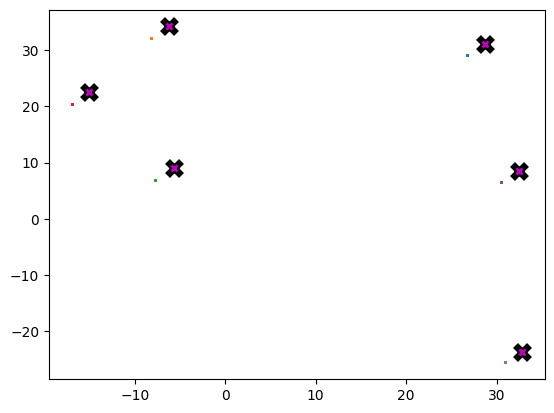

In [ ]:
plot_data(centroids+2, X, n_samples)

**Homework:** implement k-means clustering, dbscan, locality sensitive hashing, or some other clustering, fast nearest neighbors, or similar algorithm of your choice, on the GPU. Check if your version is faster than a pure python or CPU version.

Bonus: Implement it in APL too!

Super bonus: Invent a new meanshift algorithm which picks only the closest points, to avoid quadratic time.

Super super bonus: Publish a paper that describes it :D

describe k-means as describe mean shift like:
The algorithm is as follows:
* For each data point x in the sample X, find the distance between that point x and every other point in X
* Create weights for each point in X by using the **Gaussian kernel** of that point's distance to x
    * This weighting approach penalizes points further away from x
    * The rate at which the weights fall to zero is determined by the **bandwidth**, which is the standard deviation of the Gaussian
* Update x as the weighted average of all other points in X, weighted based on the previous step

This will iteratively push points that are close together even closer until they are next to each other.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Sure! Here's **k-means** described in the same style:

---

**The algorithm is as follows:**

- **Pick k** — choose the number of clusters you want, and **randomly initialize k centroids** (points that will act as cluster centers)

- **Assign each data point** to the nearest centroid (based on Euclidean distance)

- **Update each centroid** as the **mean (average) of all points assigned to it**

- **Repeat** the assignment and update steps until the centroids stop moving (or change very little)

**This will iteratively group points into clusters** by alternately:
1. deciding which points belong to which cluster
2. moving each cluster center to the middle of its assigned points

---

**Key difference from mean shift:**

| | Mean shift | k-means |
|---|---|---|
| **Needs in advance** | bandwidth | number of clusters **k** |
| **How it updates** | each point moves towards local density peaks | centroids jump to the mean of their group |
| **End result** | all points collect at density peaks | points are partitioned into **k** groups |

Would you like to try implementing k-means in code next, or maybe compare how they behave on the same dataset?

<details class='token-usage-details'><summary>$0.0042</summary>

`total=85,040 | in=84,739 | out=301 | cached=77.3% | reasoning=42 | searches=0 | $0.0042`

</details>


## K-Means

In [ ]:
k = 6

In [ ]:
centroids_idxs = torch.randperm(len(data))[:k]

In [ ]:
centroids = data.clone()[centroids_idxs]
centroids

tensor([[-11.982,   7.141],
        [ 27.161,  24.295],
        [ 30.069,  29.822],
        [ -6.934,   7.395],
        [-21.721,  21.167],
        [-15.015,  22.542]])

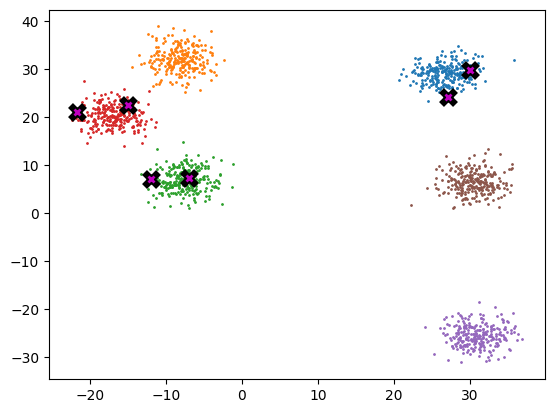

In [ ]:
plot_data(centroids, data, n_samples)

In [ ]:
X = data.clone()

In [ ]:
x = X[0]
x

tensor([26.204, 26.349])

In [ ]:
(((x - centroids)**2).sum(1)).sqrt().argmin()

tensor(1)

In [ ]:
def cluster_index(x, centroids):
    return (((x - centroids)**2).sum(1)).sqrt().argmin()

In [ ]:
cluster_index(x, centroids)

tensor(1)

tensor是否有分组的函数

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

PyTorch 本身没有直接叫 `group_by` 的函数，但你可以用几种方式来实现"分组并计算每组均值"：

**方式一：循环（简单直接）**
```python
for i in range(k):
    mask = assignments == i
    centroids[i] = X[mask].mean(0)
```

**方式二：用 scatter_add_ 做向量化版本**
可以用 `scatter_add_` 来同时累加每个组的和，再用 `scatter_add_` 统计每组个数，然后相除。

你想先试试循环的方式，还是想挑战一下向量化的写法？

<details class='token-usage-details'><summary>$0.0003</summary>

`total=86,158 | in=85,893 | out=265 | cached=98.8% | reasoning=134 | searches=0 | $0.0003`

</details>


In [ ]:
assignments = tensor([cluster_index(x, centroids) for _, x in enumerate(X)])
assignments.unique(), assignments.shape

(tensor([0, 1, 2, 3, 4, 5]), torch.Size([1500]))

In [ ]:
tensor([cluster_index(x, centroids) for i, x in enumerate(X)])

tensor([1, 2, 2,  ..., 1, 1, 1])

In [ ]:
for i in range(k):
    mask = assignments == i
    centroids[i] = X[mask].mean(0)

In [ ]:
centroids

tensor([[-10.658,   6.614],
        [ 30.090,   1.314],
        [ 27.555,  30.115],
        [  6.785,  -5.479],
        [-19.518,  20.031],
        [-11.273,  27.423]])

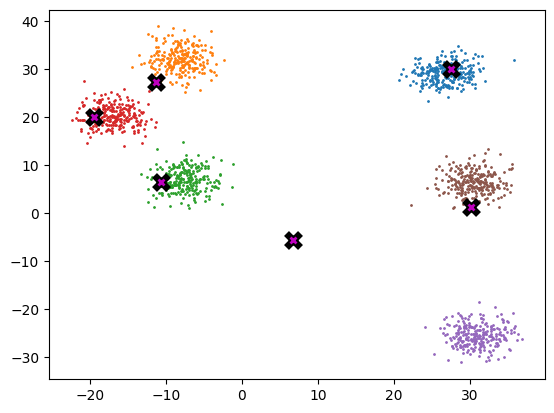

In [ ]:
plot_data(centroids, data, n_samples)

In [ ]:
def update_one(ks, d):
    assignments = tensor([cluster_index(x, ks) for _, x in enumerate(d)])
    for i in range(k):
        mask = assignments == i
        ks[i] = d[mask].mean(0)

In [ ]:
%%time

for i in range(15):
    update_one(centroids, X)

CPU times: user 221 ms, sys: 0 ns, total: 221 ms
Wall time: 220 ms


In [ ]:
centroids

tensor([[ -7.635,   6.958],
        [ 30.427,   6.500],
        [ 26.780,  29.194],
        [ 30.937, -25.434],
        [-16.998,  20.357],
        [ -8.179,  32.048]])

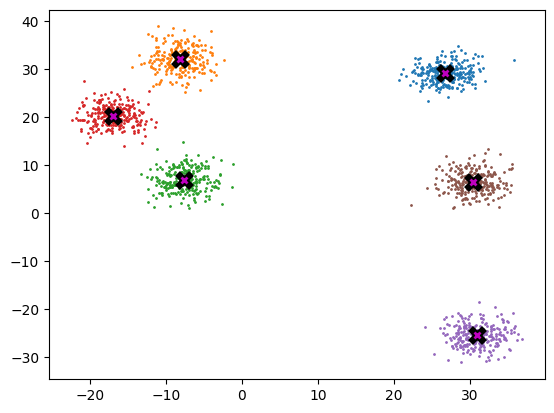

In [ ]:
plot_data(centroids, X, n_samples)

In [ ]:
bs = 5

In [ ]:
xs = X[:bs]
xs

tensor([[26.204, 26.349],
        [25.691, 30.213],
        [30.431, 28.693],
        [25.647, 30.033],
        [31.236, 30.093]])

In [ ]:
xs.shape

torch.Size([5, 2])

In [ ]:
centroids.shape

torch.Size([6, 2])

In [ ]:
xs[:, None].shape

torch.Size([5, 1, 2])

In [ ]:
centroids[None].shape

torch.Size([1, 6, 2])

In [ ]:
((xs[:, None] - centroids[None])**2).sum(-1).argmin(dim=1)

tensor([2, 2, 2, 2, 2])

给我点提示，我需要按batch对整个数据集完成操作

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

你已经找到了关键的一步——对一批点同时计算最近的质心：

```python
((xs[:, None] - centroids[None])**2).sum(-1).argmin(dim=1)
```

那对于**整个数据集**，思路是一样的，直接把 `xs` 换成 `X` 就可以了。

**提示链：**
1. 用广播一次算出所有点到所有质心的距离 → 得到形状 `[1500, 6]`
2. 用 `.argmin(dim=1)` 得到每个点的归属 → 形状 `[1500]`
3. 用这 1500 个归属标签来更新质心（你可以沿用之前的循环方式，也可以想想怎么向量化）

试试看？第一步你已经会了。

<details class='token-usage-details'><summary>$0.0001</summary>

`total=87,385 | in=87,113 | out=272 | cached=99.9% | reasoning=111 | searches=0 | $0.0001`

</details>


In [ ]:
def update_one(ks, d):
    assignments = ((d[:, None] - centroids[None])**2).sum(-1).argmin(dim=1)
    for i in range(k):
        mask = assignments == i
        ks[i] = d[mask].mean(0)

In [ ]:
X = data.clone()

In [ ]:
idxs = torch.randperm(len(X))[:k]
centroids = X[idxs]

In [ ]:
%%time

for i in range(15):
    update_one(centroids, X)

CPU times: user 4.29 ms, sys: 995 μs, total: 5.29 ms
Wall time: 4.48 ms


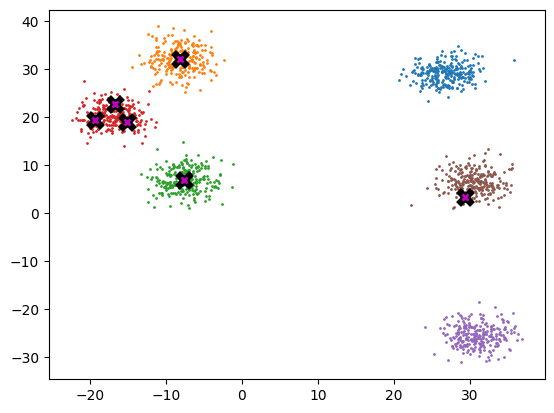

In [ ]:
plot_data(centroids, X, n_samples)

### K-means++ Init